In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import regularizers
import tensorflow as tf
from keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
print('Number of categories:',len(set(y_train)))

Number of categories: 10


In [5]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")


X_train /= 255
X_test /= 255


Y_train =  to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [6]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train)

In [7]:
print('Size of the train set:', X_train.shape)

Size of the train set: (45000, 784)


In [8]:
pesi = "problem_three.weights.h5"

In [9]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]

model = Sequential()
model.add(Dense(512, activation='relu', input_dim=input_dim,
                kernel_initializer = keras.initializers.RandomNormal(seed=se),
                kernel_regularizer=regularizers.l1(0.01)))
model.add(Dense(128, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se),
                kernel_regularizer=regularizers.l1(0.01)))
model.add(Dense(64, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se),
                kernel_regularizer=regularizers.l1(0.01)))
model.add(Dense(10, activation='softmax',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.load_weights(pesi)

model.summary()

C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
start = time.time()
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=10,
    batch_size=128
)
end = time.time()
print("Training time:", end-start)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7012 - loss: 1.6645 - val_accuracy: 0.7012 - val_loss: 1.5306
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7040 - loss: 1.5989 - val_accuracy: 0.7060 - val_loss: 1.6972
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7074 - loss: 1.5865 - val_accuracy: 0.7081 - val_loss: 1.5577
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7096 - loss: 1.5767 - val_accuracy: 0.7101 - val_loss: 1.5749
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7110 - loss: 1.5636 - val_accuracy: 0.7119 - val_loss: 1.6127
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7130 - loss: 1.5555 - val_accuracy: 0.7114 - val_loss: 1.5176
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7149 - loss: 1.5446 - val_accuracy: 0.7106 - val_loss: 1.6307
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7156 - loss: 1.5395 - val_accu

In [11]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7156 - loss: 1.4896
Test Loss: 1.4896
Test Accuracy: 0.7156


In [12]:
for layer in model.layers:
  print(layer.get_config(),
        layer.get_weights(),)

{'name': 'dense', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 512, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'RandomNormal', 'config': {'seed': 42, 'mean': 0.0, 'stddev': 0.05}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': {'module': 'keras.regularizers', 'class_name': 'L1', 'config': {'l1': 0.009999999776482582}, 'registered_name': None}, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None} [array([[ 1.16792260e-04,  1.53753572e-04, -4.14235765e-05, ...,
        -1.80595351e-04,  4.70894520e-06,  1.17899835e-04],
       [-1.62218435e-04, -4.28961903e-06,  1.73765329e-06, ...,
         4.87733996e-05, -7.85629163e-06, -5.75569866e-05],
       [ 1.13002301e-04,  3.02962690e-06,  1.1

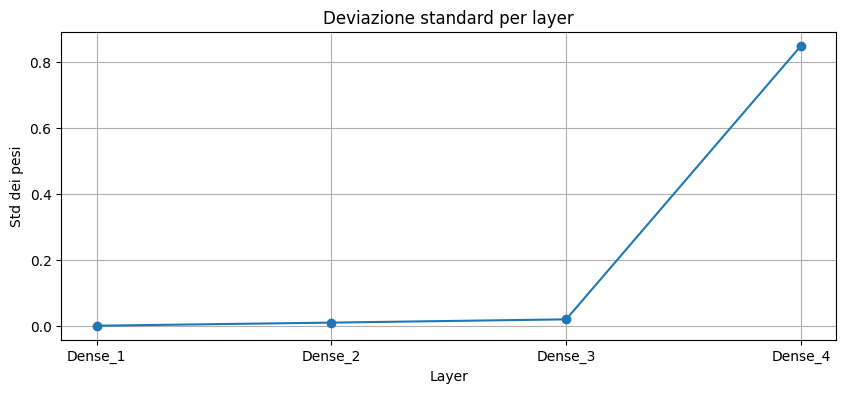

In [13]:
layer_names = []
std_weights = []
layercount = 0

for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer.png")
plt.show()

#Modello con problemi risolti

In [14]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]
reg = 0.001

model2 = Sequential()
model2.add(Dense(512, activation='relu', input_dim=input_dim,
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.4, seed=se))
model2.add(Dense(128, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.4, seed=se))
model2.add(Dense(64, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.4, seed=se))
model2.add(Dense(10, activation='softmax',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model2.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history2 = model2.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop]
)
end = time.time()

print("Training time:", end-start)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6271 - loss: 1.6221 - val_accuracy: 0.7900 - val_loss: 0.9527
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7878 - loss: 0.9212 - val_accuracy: 0.8224 - val_loss: 0.7569
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8108 - loss: 0.7743 - val_accuracy: 0.8326 - val_loss: 0.6764
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8243 - loss: 0.7027 - val_accuracy: 0.8314 - val_loss: 0.6431
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8321 - loss: 0.6635 - val_accuracy: 0.8354 - val_loss: 0.6141
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8396 - loss: 0.6303 - val_accuracy: 0.8275 - val_loss: 0.6071
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8419 - loss: 0.6108 - val_accuracy: 0.8474 - val_loss: 0.5700
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8452 - loss: 0.5976 - val_accu

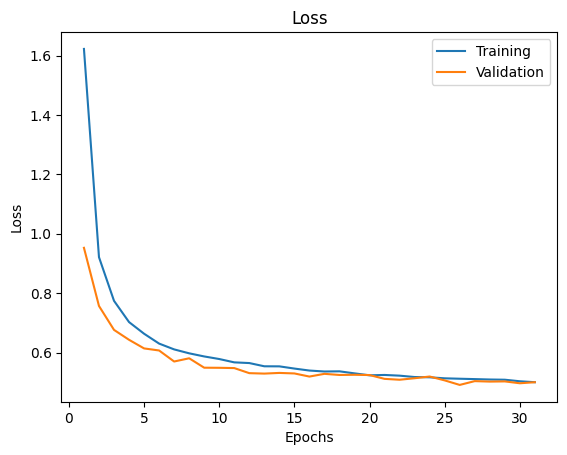

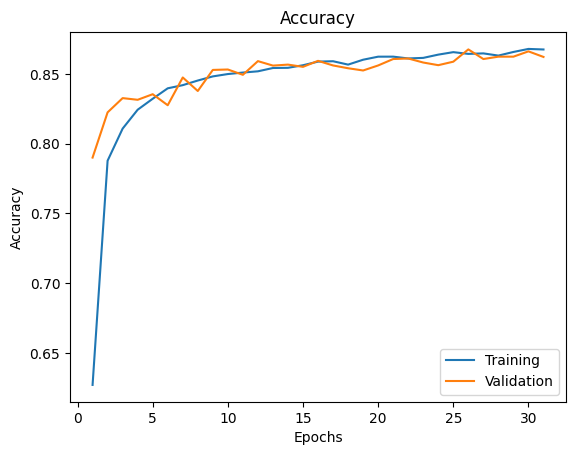

In [16]:
def plot_loss(history):
  x_plot = list(range(1,len(history.history["loss"])+1))
  plt.figure()
  plt.title("Loss")
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.plot(x_plot, history.history['loss'])
  plt.plot(x_plot, history.history['val_loss'])
  plt.legend(['Training', 'Validation'])

def plot_accuracy(history):
  x_plot = list(range(1,len(history.history["accuracy"])+1))
  plt.figure()
  plt.title("Accuracy")
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.plot(x_plot, history.history['accuracy'])
  plt.plot(x_plot, history.history['val_accuracy'])
  plt.legend(['Training', 'Validation'])

plot_loss(history2)
plt.savefig("grafici/loss2.png")
plot_accuracy(history2)
plt.savefig("grafici/accuracy2.png")

In [17]:
loss2, accuracy2 = model2.evaluate(X_test, Y_test)
print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8675 - loss: 0.4912
Test Loss: 0.4912
Test Accuracy: 0.8675


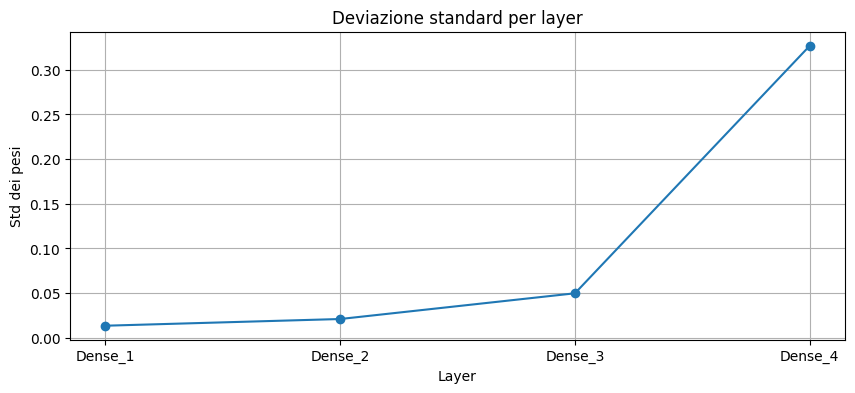

In [18]:
layer_names = []
std_weights = []
layercount = 0

for layer in model2.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer2.png")
plt.show()